In [33]:
from pathlib import Path
from IPython.display import display, Markdown

from resources.imports import *
try:
    import torch
except ModuleNotFoundError:
    torch = None

from resources.MLmetrics import (
    postprocess_list_runs,
    postprocess_artifact_table,
    postprocess_load_curve_run,
    postprocess_curve_run_overview,
    display_curve_run_overview,
    postprocess_build_active_curve_diagnostics,
    curve_summary_table,
    print_curve_diagnostics,
    display_curve_main_dashboard,
    display_curve_pointwise_summary,
    display_curve_sample_error_summary,
    display_curve_peak_energy_summary,
    display_curve_zone_summary,
    display_curve_sample_examples,
    display_curve_loss_component_breakdown,
    plot_curve_all_point_parity,
    display_curve_initial_slope_summary,
    plot_loss_history,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [34]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Find Recent Runs


In [35]:
FIND_RUN = False
RUN_ROOT = Path(r"Z:/p2")
MAX_RECENT_RUNS = 25


if FIND_RUN:
    recent_runs = postprocess_list_runs(RUN_ROOT, max_runs=MAX_RECENT_RUNS, include_hpo=True)
    display(recent_runs)
    if recent_runs.empty:
        raise ValueError("No saved runs were found. Set RUN_PATH manually.")


## 2. User Configuration


In [36]:
mechMode = "FT"
output_kind = "FieldToCurve"
model = "Transformer"
run_name = "Field2Curve-FT-test"
VIEW_MODE = "FT"
run_type = "standard"  # "standard", "model_hpo", or "cross_model_hpo"
RUN_PATH_OVERRIDE = None


if RUN_PATH_OVERRIDE is not None:
    RUN_PATH = Path(RUN_PATH_OVERRIDE)
elif run_type == "standard":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / run_name
elif run_type == "model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / "HPO" / run_name
elif run_type == "cross_model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / "HPO" / run_name / model
else:
    raise ValueError("run_type must be 'standard', 'model_hpo', or 'cross_model_hpo'.")

DATA_PATH_OVERRIDE = None
PREFER_HPO_BEST = True
ZONE_BOUNDARIES = None

if VIEW_MODE is None:
    VIEW_MODE = mechMode if str(mechMode).upper() in ["UT", "FT"] else "UT"
VIEW_MODE = str(VIEW_MODE).upper()
if VIEW_MODE not in ["UT", "FT"]:
    raise ValueError("VIEW_MODE must be UT or FT. For MULTI runs, choose which output branch to view.")

LOAD_DATA = False
LOAD_MODEL = False
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

ACTIVE_SPLIT = "test"


## 3. Load Run Artifacts


In [37]:
ARTIFACT_TABLE_KEYS = None


artifacts, loaded, DAT, MOD = postprocess_load_curve_run(
    RUN_PATH,
    run_root=RUN_ROOT,
    prefer_hpo_best=PREFER_HPO_BEST,
    load_data=LOAD_DATA,
    load_model=LOAD_MODEL,
    data_path_override=DATA_PATH_OVERRIDE,
    device=DEVICE,
)


display(postprocess_artifact_table(artifacts, keys=ARTIFACT_TABLE_KEYS))
for warning in artifacts.get("warnings", []):
    print("WARNING:", warning)


,artifact,path_or_value
0,input_path,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
1,run_dir,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
2,model_json,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
3,model_mdl,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
4,data_json,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
5,results_dir,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
6,metrics_json,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
7,predictions_npz,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
8,loss_history_csv,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
9,diagnostics_summary_json,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...


## 4. Run Setup And Available Outputs


In [38]:
SHOW_RUN_OVERVIEW = True


overview = postprocess_curve_run_overview(
    artifacts,
    loaded,
    data=DAT,
    run_name=run_name,
    run_type=run_type,
    mech_mode=mechMode,
    view_mode=VIEW_MODE,
    model_name=model,
    device=DEVICE,
    active_split=ACTIVE_SPLIT,
)


available_evals = overview["available_evals"]
available_curve_evals = overview["available_curve_evals"]
ACTIVE_SPLIT = overview["active_split"]

if SHOW_RUN_OVERVIEW:
    display_curve_run_overview(overview)
print("mechMode:", mechMode)
print("VIEW_MODE:", VIEW_MODE)
print("ACTIVE_SPLIT:", ACTIVE_SPLIT)


,item,value
0,run,Field2Curve-FT-test
1,run_type,standard
2,mechMode,FT
3,VIEW_MODE,FT
4,model,Transformer
5,output_kind,fieldtocurve
6,device,cpu
7,evaluation_split,test
8,is_hpo,False
9,model_json,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...


### Saved Metrics For Active View

,metric,value
0,FT_best_epoch,22
1,FT_best_loss,0.074878
2,FT_best_mse,0.074878
3,FT_best_rmse,"[False, 0.2736392602270572]"
4,FT_mae,5165.047945
5,FT_mse,60035932.178743
6,FT_rmse,7748.285757
7,FT_best,707
8,FT_worst,739


### Available Curve Predictions / Diagnostic Tables

,mode,split,outputs,truth,sample_metrics,point_metrics,zone_metrics
0,FT,test,True,True,True,True,True


No HPO files were found for this run.
mechMode: FT
VIEW_MODE: FT
ACTIVE_SPLIT: test


## 5. Build Active Curve Diagnostics


In [39]:
PRINT_ACTIVE_DIAGNOSTICS = True


diagnostics, active_key, active_diag = postprocess_build_active_curve_diagnostics(
    DAT,
    loaded,
    available_evals,
    view_mode=VIEW_MODE,
    active_split=ACTIVE_SPLIT,
    model=MOD,
    zone_boundaries=ZONE_BOUNDARIES,
)


if active_diag is None:
    print("No active diagnostics are available. Check predictions.npz, diagnostic CSVs, VIEW_MODE, or ACTIVE_SPLIT.")
elif PRINT_ACTIVE_DIAGNOSTICS:
    print_curve_diagnostics(active_diag, label=f"{active_key[0]} {active_key[1]}")


FT TEST prediction diagnostics | collapse ratio: 1.62e-07 | RMSE: 7748 | mean-curve RMSE: 7751 | skill vs mean curve: 0.000405 | peak corr: 0.198 | energy corr: -0.301 | sample curve corr: 0.944
FT TEST zones | elastic: collapse 2.66e-07, RMSE 818.8 | peak_region: collapse 1.84e-07, RMSE 8524 | post_peak: collapse 1.38e-07, RMSE 1.033e+04


## 6. Active Diagnostic Summary


In [40]:
SUMMARY_METRICS = [
    "rmse",
    "mae",
    "mse",
    "bias",
    "r2_global",
    "collapse_ratio",
    "mean_curve_baseline_rmse",
    "skill_vs_mean_curve_rmse",
    "mean_sample_curve_corr",
    "peak_corr",
    "peak_x_corr",
    "energy_corr",
    "n_samples",
    "n_points",
]


if active_diag is None:
    print("No active diagnostics are available.")
else:
    display(curve_summary_table(active_diag, metrics=SUMMARY_METRICS))


,metric,value
0,rmse,7.748286e+03
1,mae,5.165048e+03
2,mse,6.003593e+07
3,bias,-2.315124e+02
4,r2_global,8.502520e-01
5,collapse_ratio,1.623717e-07
6,mean_curve_baseline_rmse,7.751429e+03
7,skill_vs_mean_curve_rmse,4.054417e-04
8,mean_sample_curve_corr,9.435861e-01
9,peak_corr,1.984103e-01


## 7. Main Curve Diagnostic Dashboard


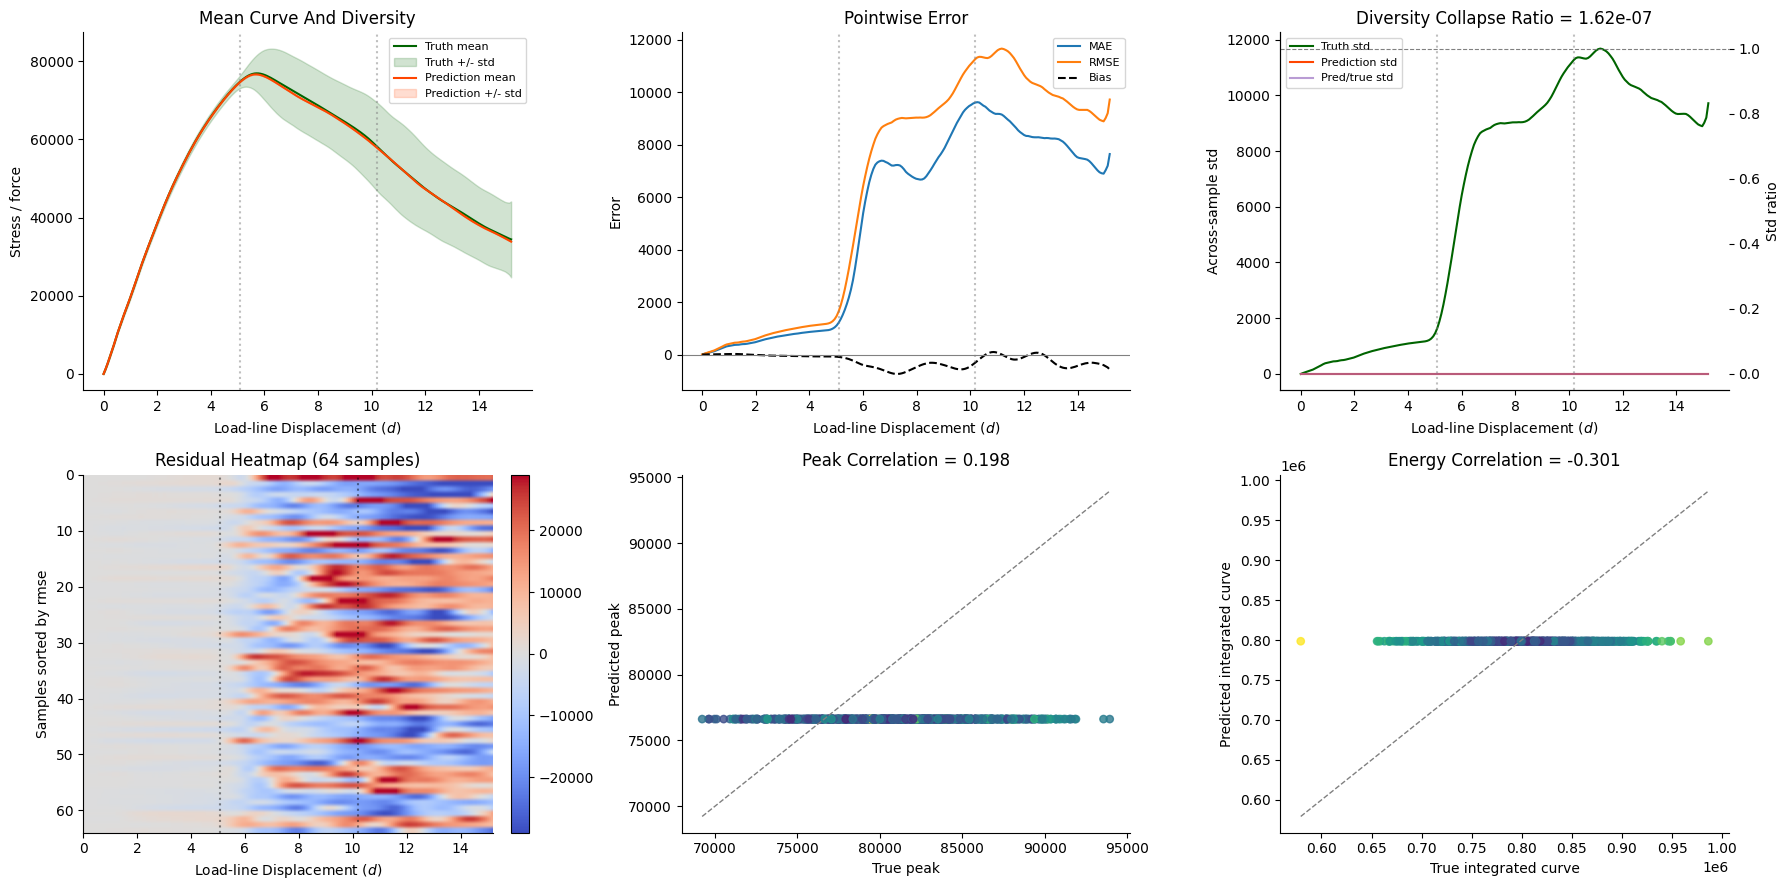

(<Figure size 1800x900 with 8 Axes>,
 array([[<Axes: title={'center': 'Mean Curve And Diversity'}, xlabel='Load-line Displacement ($d$)', ylabel='Stress / force'>,
         <Axes: title={'center': 'Pointwise Error'}, xlabel='Load-line Displacement ($d$)', ylabel='Error'>,
         <Axes: title={'center': 'Diversity Collapse Ratio = 1.62e-07'}, xlabel='Load-line Displacement ($d$)', ylabel='Across-sample std'>],
        [<Axes: title={'center': 'Residual Heatmap (64 samples)'}, xlabel='Load-line Displacement ($d$)', ylabel='Samples sorted by rmse'>,
         <Axes: title={'center': 'Peak Correlation = 0.198'}, xlabel='True peak', ylabel='Predicted peak'>,
         <Axes: title={'center': 'Energy Correlation = -0.301'}, xlabel='True integrated curve', ylabel='Predicted integrated curve'>]],
       dtype=object))

In [41]:
DASHBOARD_MAX_SAMPLES = 64
DASHBOARD_SORT_BY = "rmse"


display_curve_main_dashboard(
    active_diag,
    data=DAT,
    mode=active_key[0] if active_key is not None else VIEW_MODE,
    max_samples=DASHBOARD_MAX_SAMPLES,
    sort_by=DASHBOARD_SORT_BY,
)


## 8. Pointwise Error And Correlations


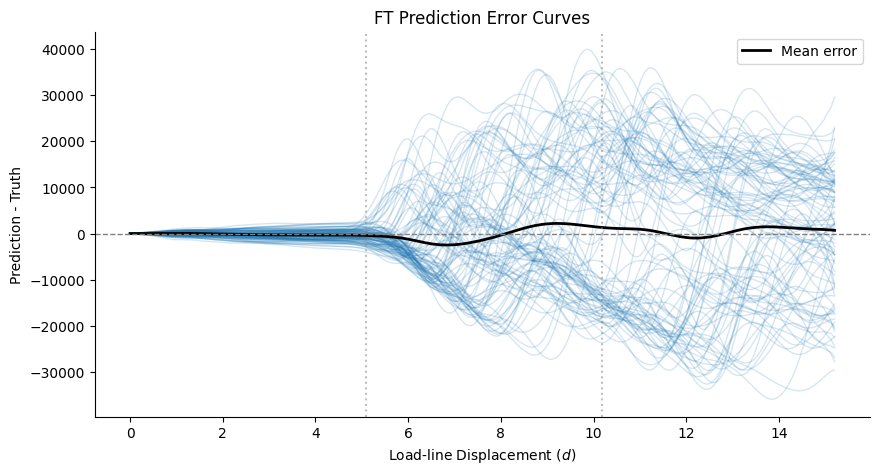

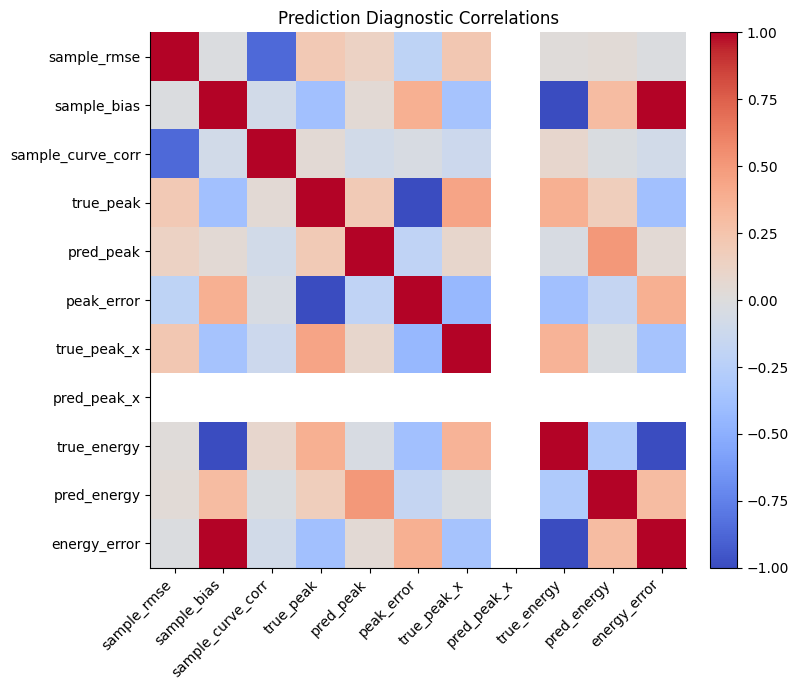

### Diagnostic Correlations

,sample_rmse,sample_bias,sample_curve_corr,true_peak,pred_peak,peak_error,true_peak_x,pred_peak_x,true_energy,pred_energy,energy_error
sample_rmse,1.000000,-0.017454,-0.863269,0.204194,0.128452,-0.204194,0.223256,NaN,0.017804,0.035061,-0.017804
sample_bias,-0.017454,1.000000,-0.078450,-0.377132,0.045875,0.377132,-0.352091,NaN,-0.999984,0.300742,0.999984
sample_curve_corr,-0.863269,-0.078450,1.000000,0.040230,-0.083366,-0.040230,-0.117417,NaN,0.078887,-0.027717,-0.078887
true_peak,0.204194,-0.377132,0.040230,1.000000,0.198410,-1.000000,0.444075,NaN,0.378087,0.170034,-0.378087
pred_peak,0.128452,0.045875,-0.083366,0.198410,1.000000,-0.198410,0.087872,NaN,-0.045715,0.501519,0.045715
peak_error,-0.204194,0.377132,-0.040230,-1.000000,-0.198410,1.000000,-0.444075,NaN,-0.378087,-0.170034,0.378087
true_peak_x,0.223256,-0.352091,-0.117417,0.444075,0.087872,-0.444075,1.000000,NaN,0.352375,-0.029063,-0.352375
pred_peak_x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
true_energy,0.017804,-0.999984,0.078887,0.378087,-0.045715,-0.378087,0.352375,NaN,1.000000,-0.300802,-1.000000
pred_energy,0.035061,0.300742,-0.027717,0.170034,0.501519,-0.170034,-0.029063,NaN,-0.300802,1.000000,0.300802


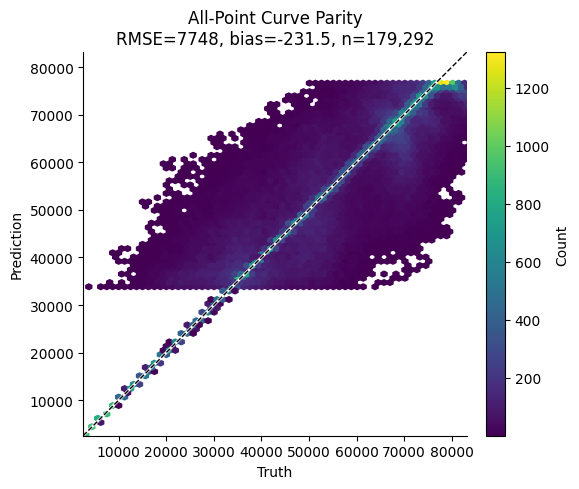

In [42]:
ERROR_CURVE_SAMPLES = 100
ERROR_CURVE_SORT_BY = "rmse"
SHOW_CORRELATION_MATRIX = True
SHOW_CURVE_PARITY = True
CURVE_PARITY_GRIDSIZE = 75
CURVE_PARITY_FIGSIZE = (6, 5)


display_curve_pointwise_summary(
    active_diag,
    data=DAT,
    mode=active_key[0] if active_key is not None else VIEW_MODE,
    max_error_curves=ERROR_CURVE_SAMPLES,
    sort_by=ERROR_CURVE_SORT_BY,
    show_correlation=SHOW_CORRELATION_MATRIX,
)

if SHOW_CURVE_PARITY:
    plot_curve_all_point_parity(
        active_diag,
        gridsize=CURVE_PARITY_GRIDSIZE,
        figsize=CURVE_PARITY_FIGSIZE,
    )


## 9. Sample-Level Error


### Best And Worst Samples By RMSE

,sample,sample_mae,sample_mse,sample_rmse,sample_bias,sample_max_abs_error,sample_curve_corr,true_peak,pred_peak,peak_error,true_peak_x,pred_peak_x,peak_x_error,true_energy,pred_energy,energy_error
707,707,1518.820606,3.988695e+06,1997.171809,258.285025,5580.753042,0.994562,79982.537902,76616.047804,-3366.490098,6.232359,5.700362,-0.531998,794559.596902,798481.021374,3921.424473
460,460,1843.739891,7.476284e+06,2734.279476,1549.923466,7337.719171,0.992520,76816.004089,76616.047457,-199.956633,5.472369,5.700362,0.227993,774729.857660,798481.028186,23751.170526
150,150,2191.018935,9.181950e+06,3030.173238,-127.456551,7920.094189,0.987505,77046.626535,76616.048120,-430.578415,5.472369,5.700362,0.227993,800433.571720,798481.023663,-1952.548057
86,86,1985.921510,9.527154e+06,3086.608896,114.502320,11695.163447,0.986488,73390.961622,76616.047598,3225.085976,5.244377,5.700362,0.455985,796830.984161,798481.018406,1650.034245
128,128,2409.343082,1.113030e+07,3336.209810,-1493.238122,6792.003204,0.987973,79765.435330,76616.048314,-3149.387015,5.928354,5.700362,-0.227993,821066.223879,798481.046347,-22585.177533
256,256,9849.077902,2.032074e+08,14255.081663,7714.013283,35825.324740,0.877570,84923.517399,76616.048563,-8307.468835,7.220387,5.700362,-1.520026,681765.552845,798481.047164,116715.494319
791,791,9634.900450,2.185967e+08,14785.017005,-9254.266729,35886.737459,0.819024,82228.788612,76616.047994,-5612.740618,6.384385,5.700362,-0.684023,939948.244611,798481.044960,-141467.199651
651,651,12358.278937,2.531006e+08,15909.135318,-12341.678240,30996.762701,0.879814,87878.348216,76616.048151,-11262.300065,7.068362,5.700362,-1.368001,986281.823794,798481.049467,-187800.774326
703,703,11427.038158,2.554266e+08,15982.071954,-10558.787780,34067.697684,0.803534,83976.260970,76616.048846,-7360.212124,7.372367,5.700362,-1.672006,958651.986320,798481.034311,-160170.952010
739,739,14563.307966,3.638316e+08,19074.369733,14400.508127,35074.831159,0.788520,79453.337186,76616.047087,-2837.290099,5.852387,5.700362,-0.152025,579284.495524,798481.043655,219196.548131


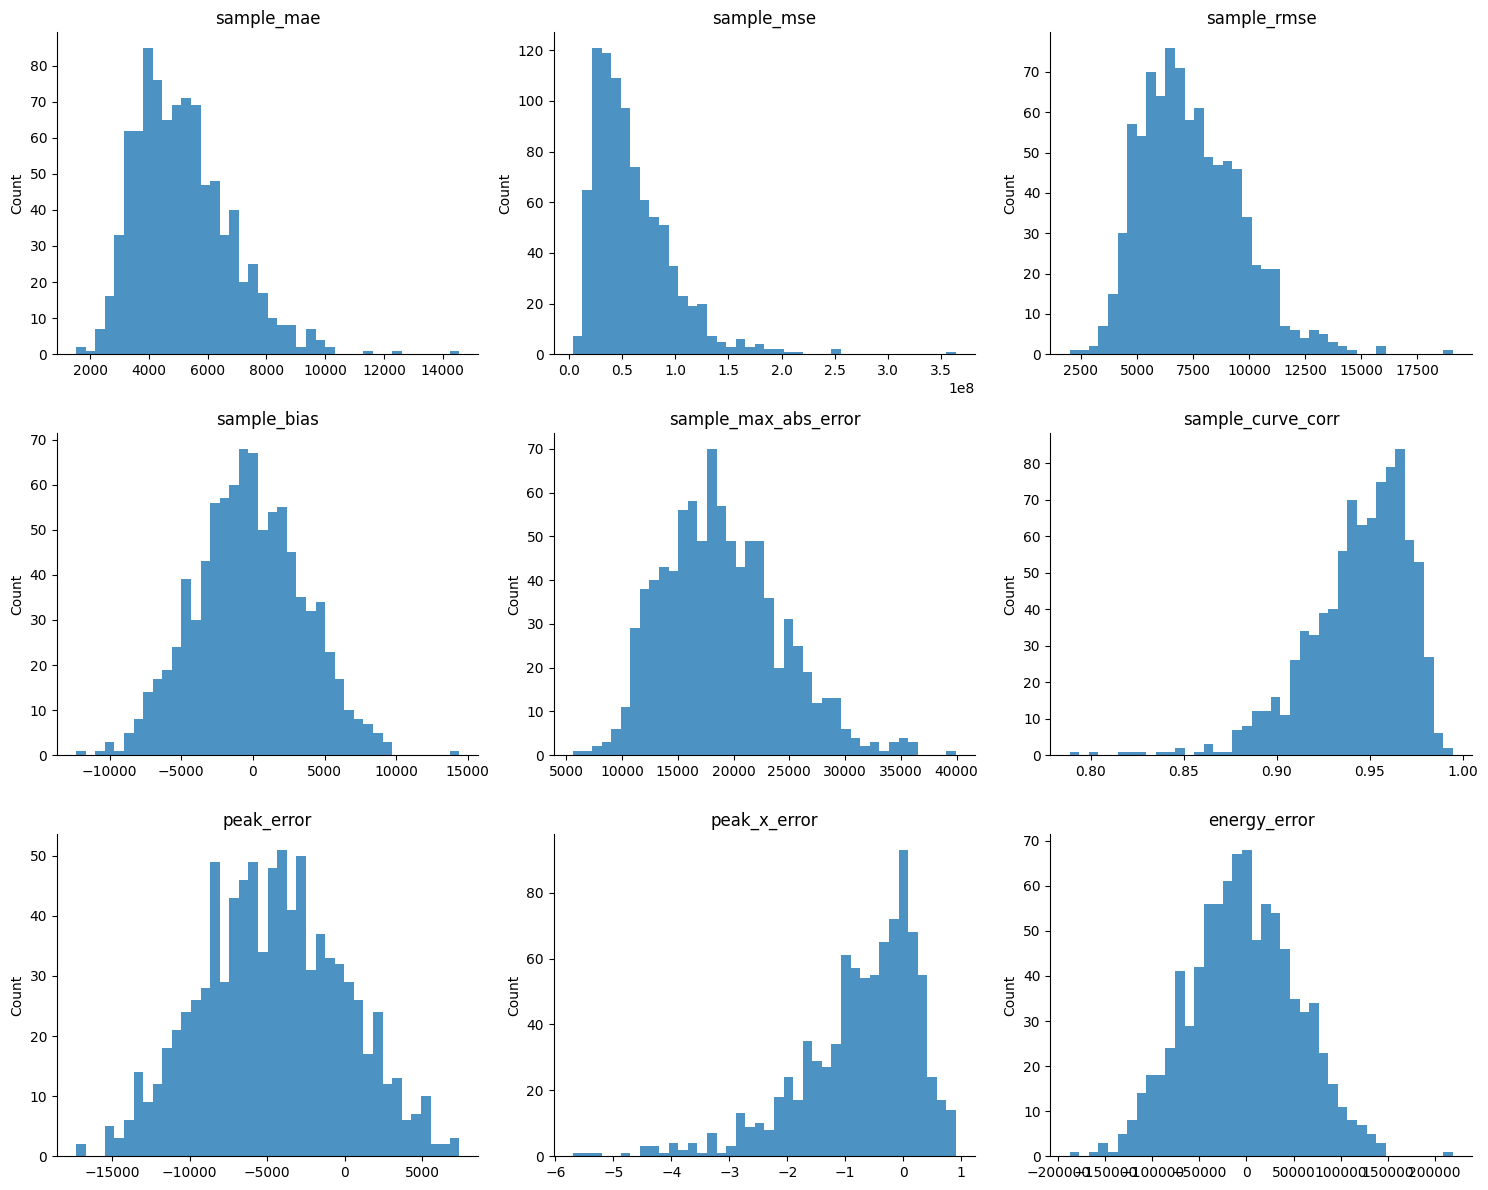

### Sample Metric Summary

,count,mean,std,min,25%,50%,75%,max
sample_mae,892.0,5.165048e+03,1.607945e+03,1.518821e+03,3.966692e+03,4.970891e+03,6.094556e+03,1.456331e+04
sample_mse,892.0,6.003593e+07,3.720393e+07,3.988695e+06,3.349279e+07,5.061525e+07,7.899762e+07,3.638316e+08
sample_rmse,892.0,7.427497e+03,2.207641e+03,1.997172e+03,5.787294e+03,7.114439e+03,8.888060e+03,1.907437e+04
sample_bias,892.0,-2.315124e+02,3.777780e+03,-1.234168e+04,-2.801024e+03,-3.038135e+02,2.329296e+03,1.440051e+04
sample_max_abs_error,892.0,1.899950e+04,5.297450e+03,5.580753e+03,1.518367e+04,1.842531e+04,2.226402e+04,3.995407e+04
sample_curve_corr,892.0,9.435861e-01,2.759462e-02,7.885201e-01,9.285434e-01,9.488700e-01,9.641155e-01,9.945621e-01
peak_error,892.0,-4.608597e+03,4.558367e+03,-1.732972e+04,-7.806311e+03,-4.647940e+03,-1.338121e+03,7.401480e+03
peak_x_error,892.0,-7.423770e-01,1.031345e+00,-5.699995e+00,-1.235024e+00,-5.319977e-01,0.000000e+00,9.119701e-01
energy_error,892.0,-3.514818e+03,5.753416e+04,-1.878008e+05,-4.260749e+04,-4.498234e+03,3.551094e+04,2.191965e+05


In [43]:
SAMPLE_DISTRIBUTION_BINS = 40
SAMPLE_DISTRIBUTION_NCOLS = 3
SAMPLE_TABLE_TOP_N = 5
SAMPLE_DESCRIBE_COLUMNS = [
    "sample_mae",
    "sample_mse",
    "sample_rmse",
    "sample_bias",
    "sample_max_abs_error",
    "sample_curve_corr",
    "peak_error",
    "peak_x_error",
    "energy_error",
]


display_curve_sample_error_summary(
    active_diag,
    bins=SAMPLE_DISTRIBUTION_BINS,
    ncols=SAMPLE_DISTRIBUTION_NCOLS,
    top_n=SAMPLE_TABLE_TOP_N,
    columns=SAMPLE_DESCRIBE_COLUMNS,
)


## 10. Initial Slope, Peak, And Energy Agreement


### Initial Slope Summary

,metric,value
0,window_start_idx,0.000000
1,window_end_idx,16.000000
2,window_start_x,0.000000
3,window_end_x,1.215823
4,window_points,17.000000
5,slope_correlation,0.037123
6,slope_mae,323.544910
7,slope_rmse,397.715156
8,slope_bias,20.177092
9,slope_median_abs_percent_error,1.401069


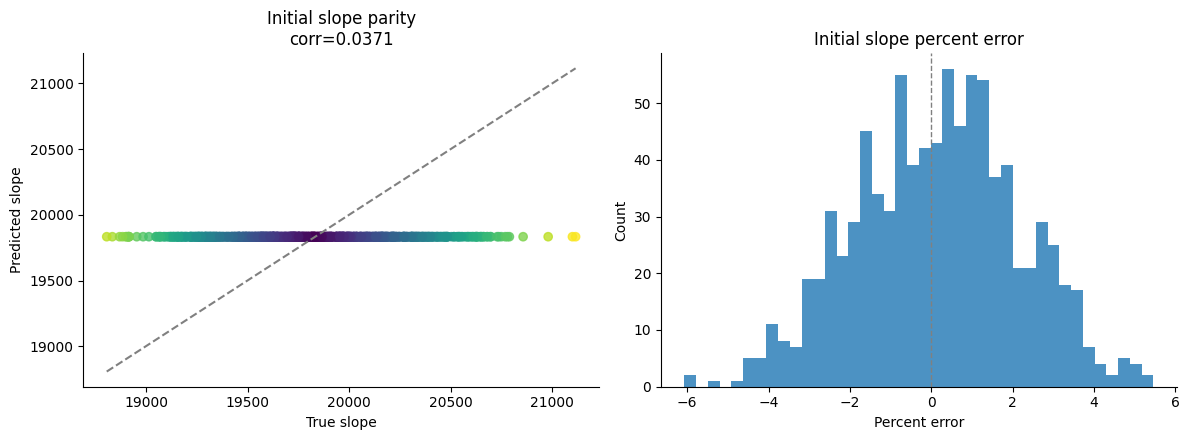

### Worst Initial Slope Samples

,sample,true_slope,pred_slope,slope_error,slope_percent_error,abs_percent_error
332,332,21115.179392,19833.333438,-1281.845954,-6.070732,6.070732
883,883,21099.528198,19833.333403,-1266.194795,-6.001057,6.001057
854,854,20980.132521,19833.333390,-1146.799131,-5.466120,5.466120
762,762,18806.930833,19833.333499,1026.402666,5.457577,5.457577
13,13,18834.557399,19833.333352,998.775953,5.302890,5.302890


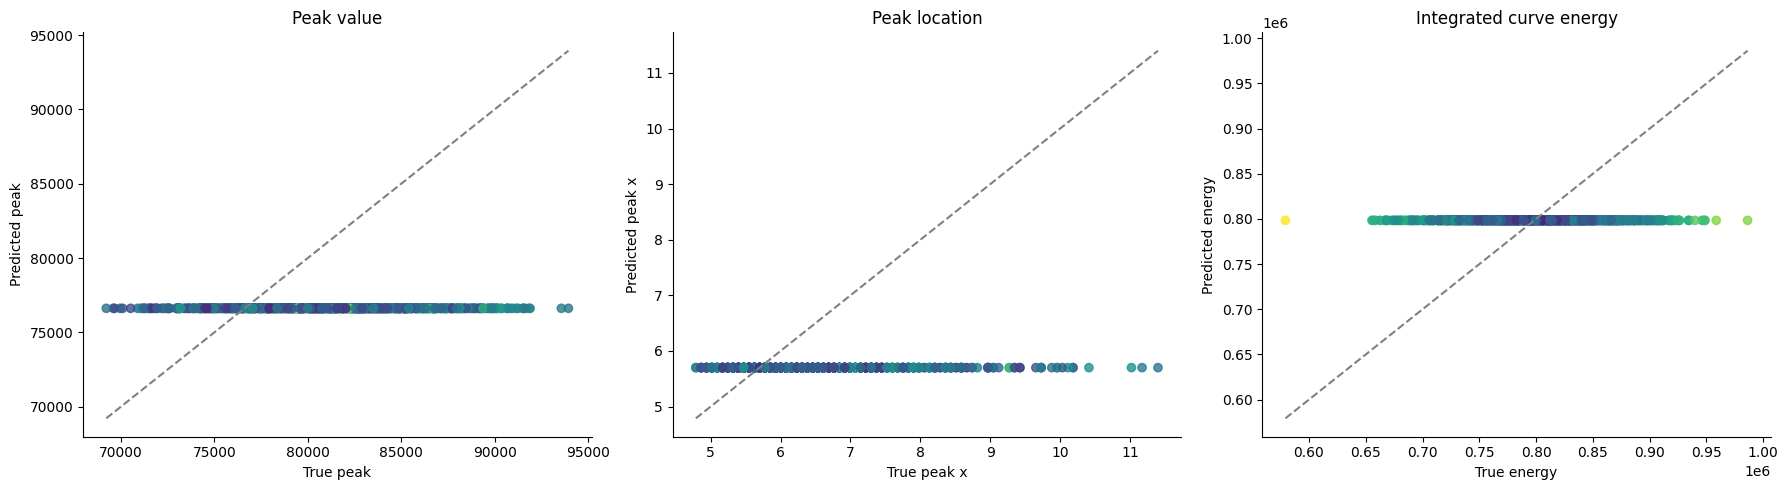

In [44]:
SHOW_INITIAL_SLOPE = True
INITIAL_SLOPE_WINDOW_FRACTION = 0.08
INITIAL_SLOPE_X_THRESHOLD = None
INITIAL_SLOPE_MIN_POINTS = 3
INITIAL_SLOPE_TOP_N = 5
SHOW_PEAK_ENERGY = True


if SHOW_INITIAL_SLOPE:
    slope_metrics_df, slope_summary = display_curve_initial_slope_summary(
        active_diag,
        window_fraction=INITIAL_SLOPE_WINDOW_FRACTION,
        x_threshold=INITIAL_SLOPE_X_THRESHOLD,
        min_points=INITIAL_SLOPE_MIN_POINTS,
        top_n=INITIAL_SLOPE_TOP_N,
    )

if SHOW_PEAK_ENERGY:
    display_curve_peak_energy_summary(active_diag)


## 11. Zone Metrics


### Zone Metrics

,zone,start_idx,end_idx,x_start,x_end,mae,mse,rmse,bias,true_std_mean,pred_std_mean,collapse_ratio
0,elastic,0,67,0.000000,5.016384,578.060128,6.704653e+05,818.819442,-30.039340,728.916154,0.000194,2.659107e-07
1,peak_region,67,134,5.092397,10.108368,6638.729275,7.265526e+07,8523.805697,-453.663813,8173.972684,0.001508,1.844339e-07
2,post_peak,134,201,10.184381,15.200355,8278.354430,1.067821e+08,10333.540908,-210.834116,10295.149245,0.001416,1.375243e-07


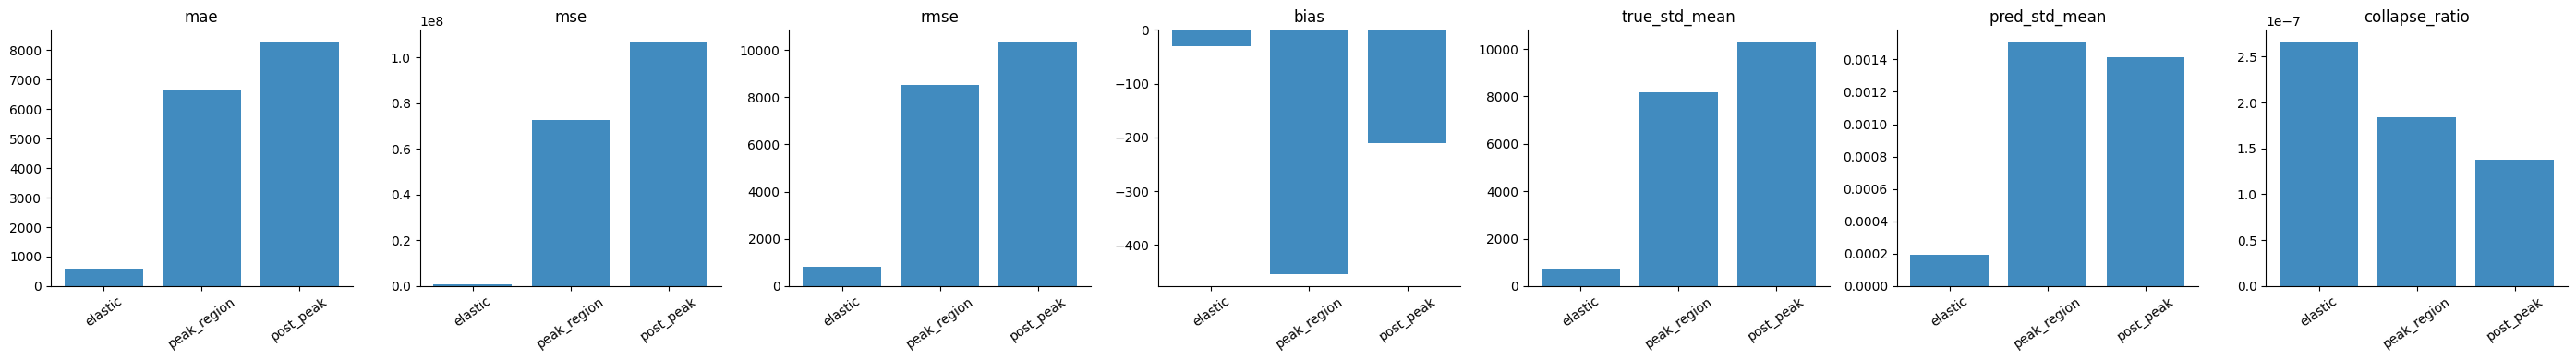

In [45]:
SHOW_ZONE_METRICS = True


if SHOW_ZONE_METRICS:
    display_curve_zone_summary(active_diag)


## 12. Selected Curve Examples


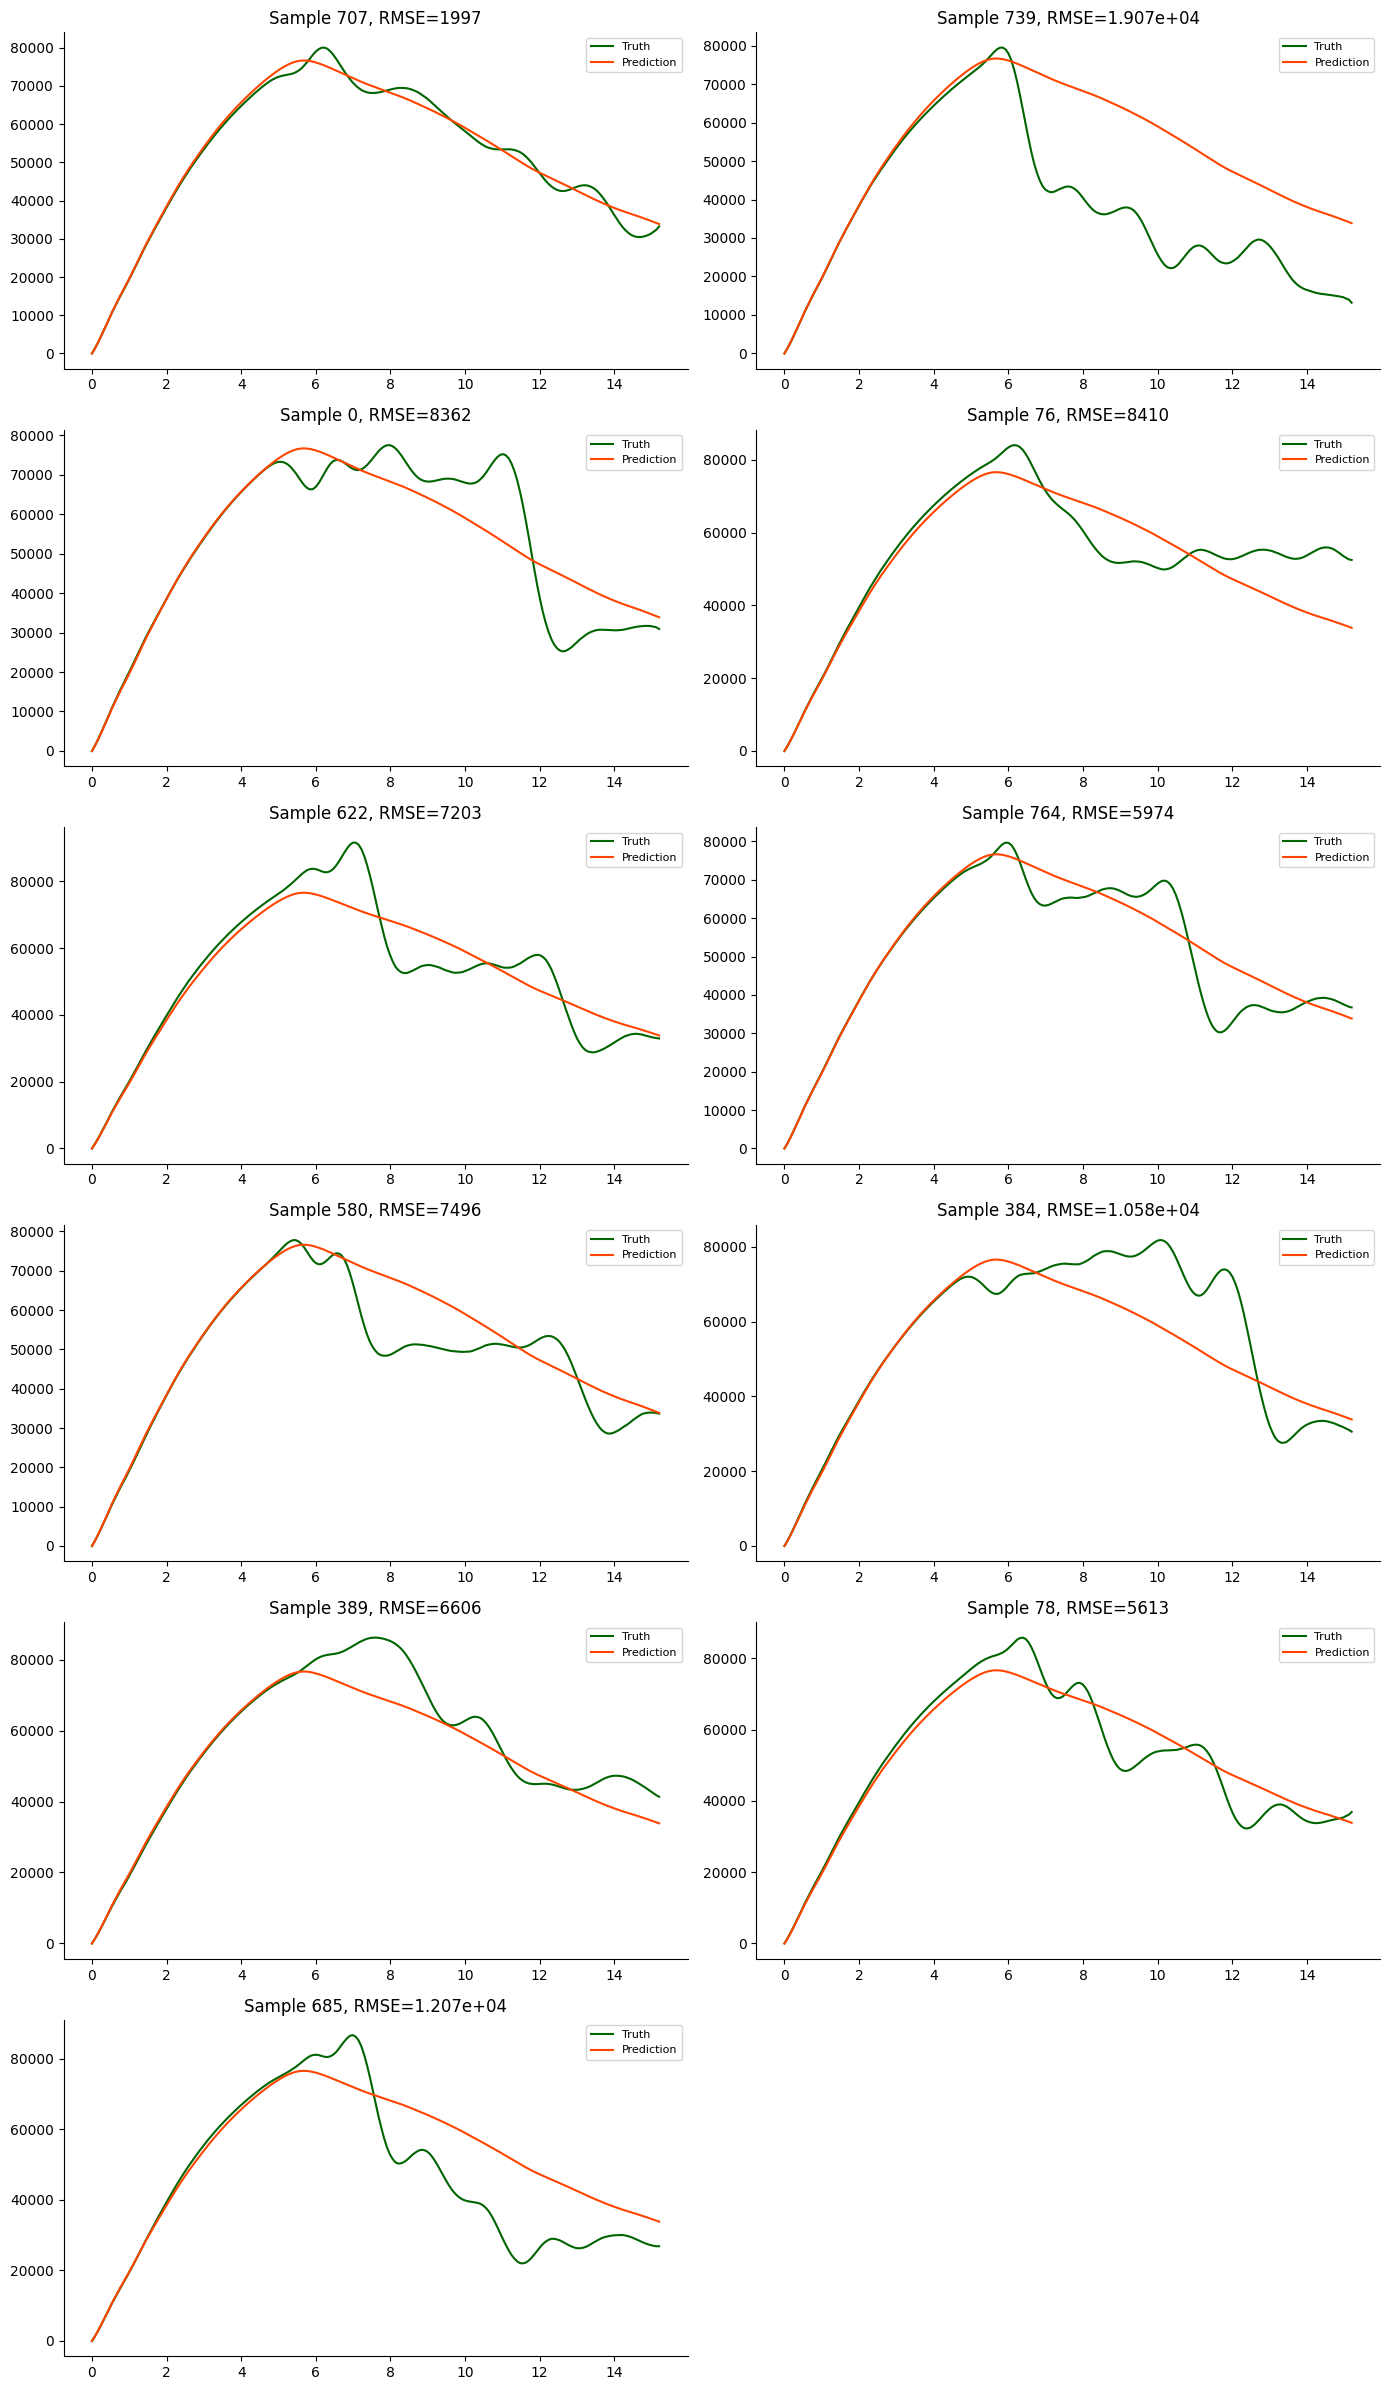

(<Figure size 1400x2400 with 12 Axes>,
 array([<Axes: title={'center': 'Sample 707, RMSE=1997'}>,
        <Axes: title={'center': 'Sample 739, RMSE=1.907e+04'}>,
        <Axes: title={'center': 'Sample 0, RMSE=8362'}>,
        <Axes: title={'center': 'Sample 76, RMSE=8410'}>,
        <Axes: title={'center': 'Sample 622, RMSE=7203'}>,
        <Axes: title={'center': 'Sample 764, RMSE=5974'}>,
        <Axes: title={'center': 'Sample 580, RMSE=7496'}>,
        <Axes: title={'center': 'Sample 384, RMSE=1.058e+04'}>,
        <Axes: title={'center': 'Sample 389, RMSE=6606'}>,
        <Axes: title={'center': 'Sample 78, RMSE=5613'}>,
        <Axes: title={'center': 'Sample 685, RMSE=1.207e+04'}>, <Axes: >],
       dtype=object))

In [46]:
SELECTED_SAMPLE = 0
RANDOM_SAMPLE_COUNT = 8
RANDOM_SEED = 42
EXAMPLE_RANK_BY = "sample_rmse"
EXAMPLE_NCOLS = 2


display_curve_sample_examples(
    active_diag,
    selected_sample=SELECTED_SAMPLE,
    random_count=RANDOM_SAMPLE_COUNT,
    random_seed=RANDOM_SEED,
    rank_by=EXAMPLE_RANK_BY,
    ncols=EXAMPLE_NCOLS,
)


## 13. Training Loss History


,mode,epoch,train_loss,val_loss
0,FT,1,0.079639,0.075202
1,FT,2,0.077344,0.076284
2,FT,3,0.076873,0.075604
3,FT,4,0.076274,0.075070
4,FT,5,0.076161,0.075015


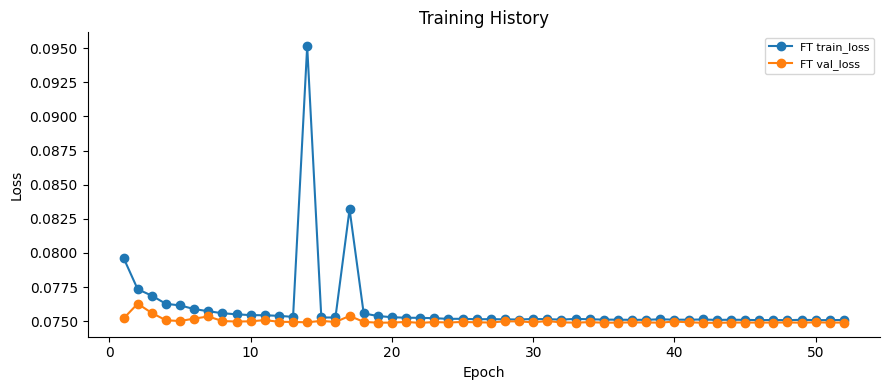

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'Training History'}, xlabel='Epoch', ylabel='Loss'>)

In [47]:
LOSS_HISTORY_METRICS = ["train_loss", "val_loss"]
LOSS_HISTORY_FIGSIZE = (9, 4)


loss_history = loaded.get("loss_history")
if loss_history is not None and hasattr(loss_history, "empty") and not loss_history.empty:
    display(loss_history.head())
plot_loss_history(loss_history, metrics=LOSS_HISTORY_METRICS, figsize=LOSS_HISTORY_FIGSIZE)


## 14. Loss Component Breakdown


In [48]:
SHOW_LOSS_COMPONENTS = True


if SHOW_LOSS_COMPONENTS:
    loss_components_df = display_curve_loss_component_breakdown(MOD, active_diag, active_key=active_key)


MODEL is not loaded, so loss components cannot be evaluated.
